# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
A model is linear if it is linear in the coefficients
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?) 
A dummy variable coefficient shows how much the outcome changes compared to the reference group, which is captured by the intercept.
3. Can linear regression be used for classification? Explain why, or why not.
Linear regression is not useful for classification because it doesnt represent probabilities that good. Predictions can fall below 0 or above 1 and that isn't ideal. 
4. What are signs that your linear model is over-fitting?
When the model fits training data well but test data poorly.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
It means when predicting varriables are correlated and it is hard to differentiate their effects which causes unstable coefficients.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
You can add logarithms, squared terms, etc.
7. What is the interpretation of the slope coefficient in a linear regression?
The slope represents a how much y is increased/decreased corresponding to when x changes.
8.  Compare the train/test split and $k$-fold cross validation.
Train/test split uses one split where it divides the data into two parts. k-fold cross validation repeatedly splits data into different parts to evaluate the models better.
9.  How is the $k$ in $k$-fold cross validation typically selected?
it is usually chosen as 5 or 10 to best balance the accuracy.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

df = pd.read_csv('./data/Q1_clean.csv')
df = df.rename(columns={'Review Scores Rating': 'Review_Scores_Rating'})
df.columns = df.columns.str.strip().str.lower()
df.head()

,price,review_scores_rating,neighbourhood,property type,room type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


## 1)

In [20]:
avg_table = df.groupby('neighbourhood')[['price', 'review_scores_rating']].mean()
print(avg_table)

print("Most expensive:", avg_table['price'].idxmax())

                    price  review_scores_rating
neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
Most expensive: Manhattan


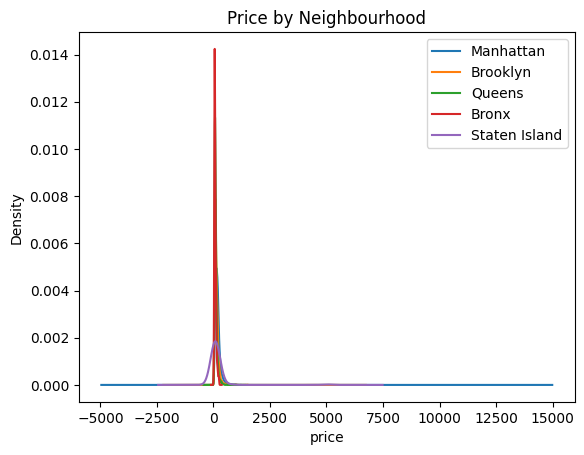

In [21]:
for area in df['neighbourhood'].unique():
    df[df['neighbourhood'] == area]['price'].plot.kde(label=area)

plt.xlabel('price')
plt.title('Price by Neighbourhood')
plt.legend()
plt.show()

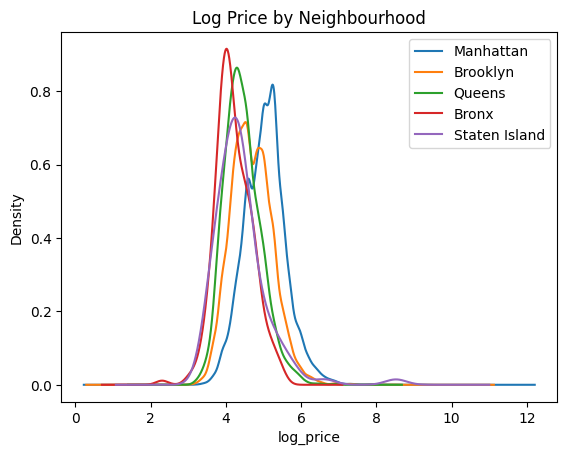

In [22]:
df['log_price'] = np.log(df['price'])

for area in df['neighbourhood'].unique():
    df[df['neighbourhood'] == area]['log_price'].plot.kde(label=area)

plt.xlabel('log_price')
plt.title('Log Price by Neighbourhood')
plt.legend()
plt.show()

The price distribution was bad because of outlying values. After using the log transformation, we can see that Manhattan is the most expensive place on average.

## 2)

In [23]:
X = pd.get_dummies(df['neighbourhood'], drop_first=True)
y = df['price']

model1 = LinearRegression()
model1.fit(X, y)

print("Intercept:", model1.intercept_)
print("Coefficients:", model1.coef_)
print("Columns:", X.columns)

Intercept: 75.27649769584667
Coefficients: [ 52.47088065 108.38778863  21.58073501  70.89016897]
Columns: Index(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island'], dtype='object')


The intercept is the mean price for the reference neighborhood, and each dummy coefficient shows the difference from that group. The regression coefficients are directly related to the group means from part 1.

## 3)

In [25]:
X = df[['review_scores_rating']]
y = df['price']

model2 = LinearRegression()
model2.fit(X, y)

print("Intercept:", model2.intercept_)
print("Slope:", model2.coef_[0])

Intercept: 60.878390657123816
Slope: 1.0208266022674735


The slope shows that for every 1-point increase in review score, the price increases by about $1.02 on average. This means higher-rated listings tend to have higher prices.

## 4)

In [26]:
X = pd.concat([
    df[['review_scores_rating']],
    pd.get_dummies(df['neighbourhood'], drop_first=True)
], axis=1)

y = df['price']

model3 = LinearRegression()
model3.fit(X, y)

coef_table3 = pd.DataFrame({
    'variable': ['intercept'] + list(X.columns),
    'coefficient': [model3.intercept_] + list(model3.coef_)
})
print(coef_table3)

               variable  coefficient
0             intercept   -23.812561
1  review_scores_rating     1.081116
2              Brooklyn    51.704240
3             Manhattan   108.228737
4                Queens    21.694600
5         Staten Island    71.766552


Higher review scores slightly increase price. Compared to the reference neighborhood, Manhattan is the most expensive, followed by Staten Island, Brooklyn, and Queens.

## 5)

In [27]:
dummies = pd.get_dummies(df['neighbourhood'], drop_first=True)

X = pd.concat([df[['review_scores_rating']], dummies], axis=1)

for col in dummies.columns:
    X[col + '_x_rating'] = dummies[col] * df['review_scores_rating']

y = df['price']

model4 = LinearRegression()
model4.fit(X, y)

coef_table4 = pd.DataFrame({
    'variable': ['intercept'] + list(X.columns),
    'coefficient': [model4.intercept_] + list(model4.coef_)
})
print(coef_table4)

                 variable  coefficient
0               intercept    22.638385
1    review_scores_rating     0.574311
2                Brooklyn   -16.392990
3               Manhattan    41.315429
4                  Queens    28.259701
5           Staten Island  2963.071040
6       Brooklyn_x_rating     0.741165
7      Manhattan_x_rating     0.729703
8         Queens_x_rating    -0.072294
9  Staten Island_x_rating   -31.831748


This model shows the effect of the review score being different in each neighborhood. Some neughborhoods have similar slopes, while other vary greatly. This shows that the relationship between rating and price is not the same

## 6)

In [28]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
y = df['price']

Part 3

In [29]:
X1 = df[['review_scores_rating']]
cv1 = cross_val_score(LinearRegression(), X1, y, cv=kf, scoring='neg_mean_squared_error')
print("Model 1 CV MSE:", -cv1.mean())

Model 1 CV MSE: 22078.215444464753


Part 4

In [31]:
X2 = pd.concat([
    df[['review_scores_rating']],
    pd.get_dummies(df['neighbourhood'], drop_first=True)
], axis=1)

cv2 = cross_val_score(LinearRegression(), X2, y, cv=kf, scoring='neg_mean_squared_error')
print("Model 2 CV MSE:", -cv2.mean())

Model 2 CV MSE: 21068.500019790667


Part 5

In [32]:
dummies = pd.get_dummies(df['neighbourhood'], drop_first=True)

X3 = pd.concat([df[['review_scores_rating']], dummies], axis=1)

for col in dummies.columns:
    X3[col + '_x_rating'] = dummies[col] * df['review_scores_rating']

cv3 = cross_val_score(LinearRegression(), X3, y, cv=kf, scoring='neg_mean_squared_error')
print("Model 3 CV MSE:", -cv3.mean())

Model 3 CV MSE: 21293.768998593343


Since model 2 has the lowest CV MSE, it performs best on new data. 

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
